In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet

from sklearn.ensemble import HistGradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder

import optuna
import lightgbm as lgb
import shap
from optuna.integration import LightGBMPruningCallback
 
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings

In [131]:
df = pd.read_csv("../data/processed/rideshare_feature_engineering.csv")

In [132]:
df.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,log_distance,surge_intensity,price_per_mile,is_surge,source_avg_price,dest_avg_price,cab_type_enc,destination_enc,route_frequency,source_enc
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,0.364643,0.0,11.337868,0,13.578114,16.805238,1,7,8874,5
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,0.364643,0.0,24.943311,0,13.578114,16.805238,1,7,8874,5
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,0.364643,0.0,15.873016,0,13.578114,16.805238,1,7,8874,5
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,...,0.364643,0.0,58.956916,0,13.578114,16.805238,1,7,8874,5
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,...,0.364643,0.0,20.408163,0,13.578114,16.805238,1,7,8874,5


In [133]:
df.columns

Index(['hour', 'day', 'month', 'source', 'destination', 'cab_type', 'name',
       'price', 'distance', 'surge_multiplier', 'latitude', 'longitude',
       'temperature', 'apparentTemperature', 'short_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax', 'tier', 'route',
       'log_price', 'tier_enc', 'name_enc', 'surge_x_distance', 'log_distance',
       'surge_intensity', 'price_per_mile', 'is_surge', 'source_avg_price',
       'dest_avg_price', 'cab_type_enc', 'destination_enc', 'route_frequency',
       'source_enc'],
      dtype='str')

In [134]:
print(df.select_dtypes(include=['object']).columns)

Index(['source', 'destination', 'cab_type', 'name', 'short_summary', 'tier',
       'route'],
      dtype='str')


In [135]:
df['dist_x_surge_freq'] = df['distance'] * df['surge_multiplier'] / (df['route_frequency'] + 1)
df['dist_per_route'] = df['distance'] / (df['route_frequency'] + 1)
df['price_pressure']     = df['distance'] / (df['route_frequency'] + 1) * df['surge_multiplier']

In [136]:
weather = ['latitude', 'longitude',
       'temperature', 'apparentTemperature', 'short_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax']

time = ['hour', 'day', 'month']


data_leakage =  ['source_avg_price','dest_avg_price', 'log_price', 'price_per_mile', 'tier_enc', 'name_enc', 'cab_type_enc', 'destination_enc', 'source_enc']

drop_columns = weather + time + data_leakage

df = df.drop(columns=drop_columns, errors='ignore')

In [137]:
df.columns

Index(['source', 'destination', 'cab_type', 'name', 'price', 'distance',
       'surge_multiplier', 'tier', 'route', 'surge_x_distance', 'log_distance',
       'surge_intensity', 'is_surge', 'route_frequency', 'dist_x_surge_freq',
       'dist_per_route', 'price_pressure'],
      dtype='str')

In [138]:
numeric_cols = [
    'surge_multiplier', 'surge_x_distance', 'distance',
    'log_distance', 'surge_intensity', 'is_surge',
    'route_frequency', 'dist_x_surge_freq', 'dist_per_route', 'price_pressure'
]

categorical_cols = ['source', 'destination', 'cab_type', 'name', 'tier', 'route']

feature_cols = numeric_cols + categorical_cols

In [139]:
df_uber = df[df['cab_type'] == 'Uber'].copy().reset_index(drop=True)
df_lyft = df[df['cab_type'] == 'Lyft'].copy().reset_index(drop=True)
 
print(f"Uber: {len(df_uber):,} rows | Lyft: {len(df_lyft):,} rows | Total: {len(df):,} rows")

Uber: 330,568 rows | Lyft: 307,408 rows | Total: 637,976 rows


In [140]:
def make_split(df_sub, stratify_col='tier'):
    # แยก train/test พร้อม encode categorical
    X = df_sub[feature_cols].copy()
    y = df_sub['price'].copy()
 
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=df_sub[stratify_col]   # รักษา tier ratio ใน train/test
    )
 
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_tr = X_tr.copy()
    X_te = X_te.copy()
    X_tr[categorical_cols] = enc.fit_transform(X_tr[categorical_cols])
    X_te[categorical_cols] = enc.transform(X_te[categorical_cols])
 
    return X_tr, X_te, y_tr, y_te, enc

In [141]:
X_tr_uber, X_te_uber, y_tr_uber, y_te_uber, enc_uber = make_split(df_uber)
X_tr_lyft, X_te_lyft, y_tr_lyft, y_te_lyft, enc_lyft = make_split(df_lyft)
 
# Combined — stratify ด้วย cab_type แทน
X_tr_all, X_te_all, y_tr_all, y_te_all, enc_all = make_split(df, stratify_col='cab_type')

In [142]:
# Baseline
# Linear Models แก้ Overfit ด้วย Regularization
# XGBoost
# HistGradientBoosting
# LightGBM

coarse_configs = [
    {
        'name': 'LinearReg',
        'model': LinearRegression(),
        'params': {}
    },
    {
        'name': 'Lasso',
        'model': Lasso(),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    {
        'name': 'ElasticNet',
        'model': ElasticNet(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10],
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBRegressor(n_jobs=-1, random_state=42),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9]
        }
    },
    {
        'name': 'HistGBM',
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [1000, 2000, 5000],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'num_leaves': [7, 31, 127]
        }
    }
]

In [143]:
datasets = {
    'Uber':     (X_tr_uber, y_tr_uber),
    'Lyft':     (X_tr_lyft, y_tr_lyft),
    'Combined': (X_tr_all,  y_tr_all),
}

In [144]:
# Coarse Search
warnings.filterwarnings('ignore')
coarse_results = [] # ใช้เป็น List ถูกต้องแล้ว เพื่อให้แปลงเป็น DataFrame ง่ายๆ

for ds_name, (X_tr, y_tr) in datasets.items():
    print(f"\n{'='*50}")
    print(f"Coarse Search — {ds_name}")
    print(f"{'Model':<12} | {'RMSE':<10} | Best Params")
 
    for cfg in coarse_configs:
        search = RandomizedSearchCV(
            cfg['model'], cfg['params'],
            n_iter=5, cv=3,
            scoring='neg_mean_squared_error',
            n_jobs=-1, random_state=42
        )
        search.fit(X_tr, y_tr)
        rmse = np.sqrt(-search.best_score_)
        
        # เก็บข้อมูลทั้งชื่อ Dataset, ชื่อ Model, RMSE และ Params ลง List
        coarse_results.append({
            'Dataset': ds_name,
            'Model': cfg['name'],
            'RMSE': rmse,
            'Best Params': search.best_params_
        })
        print(f"{cfg['name']:<12} | {rmse:<10.4f} | {search.best_params_}")


Coarse Search — Uber
Model        | RMSE       | Best Params
LinearReg    | 4.6019     | {}
Lasso        | 4.6034     | {'alpha': 0.001}
ElasticNet   | 4.6033     | {'l1_ratio': 0.2, 'alpha': 0.001}
XGBoost      | 1.8553     | {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2}
HistGBM      | 1.8531     | {'max_iter': 1000, 'max_depth': 6, 'learning_rate': 0.2}
LightGBM     | 1.9113     | {'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}

Coarse Search — Lyft
Model        | RMSE       | Best Params
LinearReg    | 3.7705     | {}
Lasso        | 3.7707     | {'alpha': 0.001}
ElasticNet   | 3.7721     | {'l1_ratio': 0.2, 'alpha': 0.001}
XGBoost      | 1.3403     | {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2}
HistGBM      | 1.3067     | {'max_iter': 2000, 'max_depth': 6, 'learning_rate': 0.1}
LightGBM     | 1.5014     | {'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}

Coarse Search — Combined
Model        | R

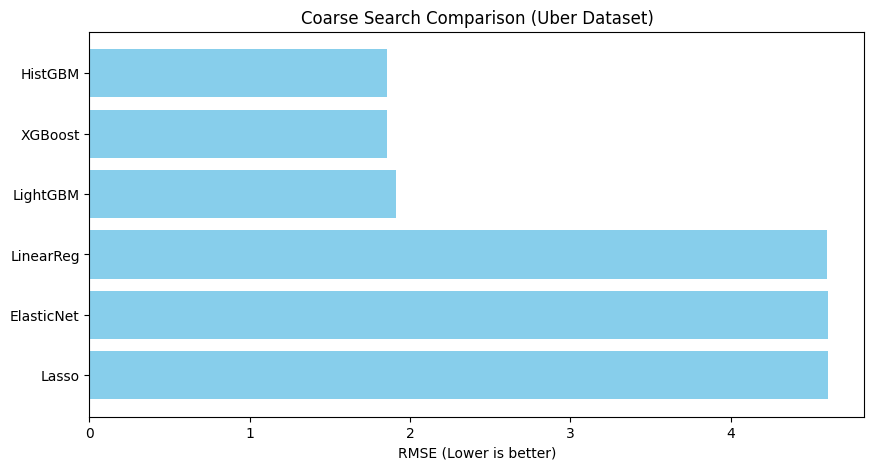

In [145]:
# แปลงเป็น DataFrame (คราวนี้จะมีคอลัมน์ Dataset, Model, RMSE ชัดเจน)
res_df = pd.DataFrame(coarse_results)

# 💡 เนื่องจากตอนนี้เรามีหลาย Dataset (Uber, Lyft, Combined) 
# การพล็อตกราฟแท่งรวมกันทั้งหมดอาจจะดูยาก เราจึงขอเลือกพล็อตเฉพาะ 'Combined' เป็นตัวอย่าง
res_plot = res_df[res_df['Dataset'] == 'Uber'].sort_values('RMSE')

plt.figure(figsize=(10, 5))
plt.barh(res_plot['Model'], res_plot['RMSE'], color='skyblue')
plt.xlabel('RMSE (Lower is better)')
plt.title('Coarse Search Comparison (Uber Dataset)')
plt.gca().invert_yaxis()
plt.show()

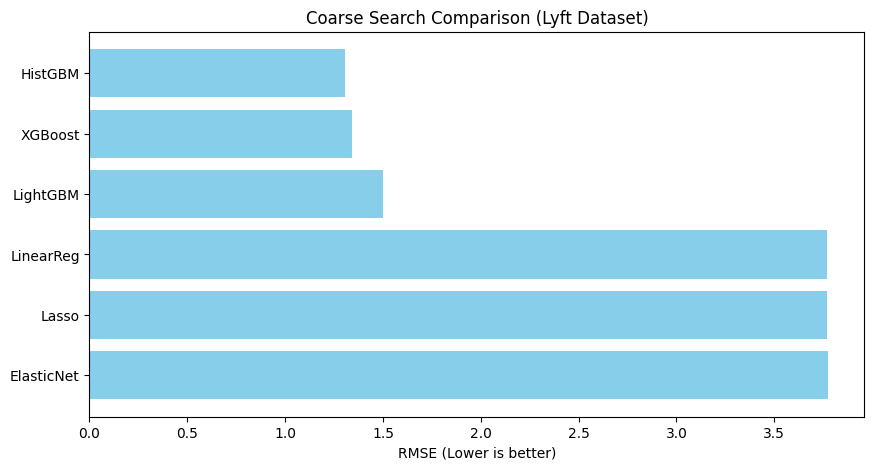

In [146]:
# แปลงเป็น DataFrame (คราวนี้จะมีคอลัมน์ Dataset, Model, RMSE ชัดเจน)
res_df = pd.DataFrame(coarse_results)

# 💡 เนื่องจากตอนนี้เรามีหลาย Dataset (Uber, Lyft, Combined) 
# การพล็อตกราฟแท่งรวมกันทั้งหมดอาจจะดูยาก เราจึงขอเลือกพล็อตเฉพาะ 'Combined' เป็นตัวอย่าง
res_plot = res_df[res_df['Dataset'] == 'Lyft'].sort_values('RMSE')

plt.figure(figsize=(10, 5))
plt.barh(res_plot['Model'], res_plot['RMSE'], color='skyblue')
plt.xlabel('RMSE (Lower is better)')
plt.title('Coarse Search Comparison (Lyft Dataset)')
plt.gca().invert_yaxis()
plt.show()

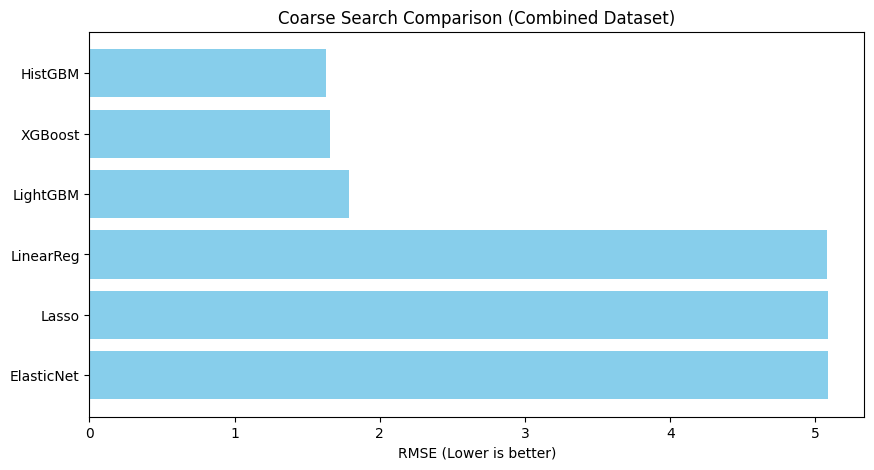

In [147]:
# แปลงเป็น DataFrame (คราวนี้จะมีคอลัมน์ Dataset, Model, RMSE ชัดเจน)
res_df = pd.DataFrame(coarse_results)

# 💡 เนื่องจากตอนนี้เรามีหลาย Dataset (Uber, Lyft, Combined) 
# การพล็อตกราฟแท่งรวมกันทั้งหมดอาจจะดูยาก เราจึงขอเลือกพล็อตเฉพาะ 'Combined' เป็นตัวอย่าง
res_plot = res_df[res_df['Dataset'] == 'Combined'].sort_values('RMSE')

plt.figure(figsize=(10, 5))
plt.barh(res_plot['Model'], res_plot['RMSE'], color='skyblue')
plt.xlabel('RMSE (Lower is better)')
plt.title('Coarse Search Comparison (Combined Dataset)')
plt.gca().invert_yaxis()
plt.show()

In [148]:
N_TRIALS = 30

def tune_with_optuna(X_tr, y_tr, X_te, y_te, coarse_params, dataset_name, model_type='LightGBM'):
    # ดึง best params จาก coarse มาเป็นจุดตั้งต้น
    c = coarse_params.get(model_type, {})
    base_lr = c.get('learning_rate', 0.1)
    base_depth = c.get('max_depth', 6)

    # แบ่ง validation set จาก train
    X_t, X_v, y_t, y_v = train_test_split(X_tr, y_tr, test_size=0.15, random_state=42)

    def objective(trial):
        if model_type == 'LightGBM':
            base_leaves = c.get('num_leaves', 31)
            params = {
                'n_estimators': 5000,
                'learning_rate': trial.suggest_float('learning_rate', max(0.005, base_lr * 0.5), min(0.3, base_lr * 2.0), log=True),
                'num_leaves': trial.suggest_int('num_leaves', max(7, base_leaves // 2), min(255, base_leaves * 2)),
                'max_depth': trial.suggest_int('max_depth', max(2, base_depth - 2), min(12, base_depth + 2)),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
                'subsample': trial.suggest_float('subsample', 0.7, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
                'random_state': 42, 'n_jobs': -1, 'verbose': -1,
            }
            model = LGBMRegressor(**params)
            model.fit(
                X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='rmse',
                callbacks=[lgb.early_stopping(50, verbose=False), LightGBMPruningCallback(trial, 'rmse')]
            )
            trial.set_user_attr('best_iteration', model.best_iteration_)
            preds = model.predict(X_v)
            
        elif model_type == 'HistGBM':
            params = {
                'max_iter': 5000, # ให้วิ่งสุดแล้วใช้ early stopping ตัด
                'learning_rate': trial.suggest_float('learning_rate', max(0.005, base_lr * 0.5), min(0.3, base_lr * 2.0), log=True),
                'max_depth': trial.suggest_int('max_depth', max(2, base_depth - 2), min(12, base_depth + 2)),
                'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 255),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
                'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 5.0, log=True),
                'random_state': 42,
                'early_stopping': True,
                'validation_fraction': 0.15,
                'n_iter_no_change': 50
            }
            model = HistGradientBoostingRegressor(**params)
            # ป้อน X_t เข้าไป ระบบจะกัน validation_fraction ในตัวมันเองอีกชั้นเพื่อตัดจบ
            model.fit(X_t, y_t)
            trial.set_user_attr('best_iteration', model.n_iter_)
            preds = model.predict(X_v)

        return np.sqrt(mean_squared_error(y_v, preds))

    print(f"\n{'='*50}")
    print(f"Optuna Tuning — {dataset_name} [{model_type}] ({N_TRIALS} trials)")
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=N_TRIALS, timeout=600)

    # Train final model ด้วย best params
    best_params = study.best_params.copy()
    best_params['random_state'] = 42
    
    if model_type == 'LightGBM':
        best_params['n_estimators'] = study.best_trial.user_attrs['best_iteration']
        best_params.update({'n_jobs': -1, 'verbose': -1})
        final_model = LGBMRegressor(**best_params)
    elif model_type == 'HistGBM':
        best_params['max_iter'] = study.best_trial.user_attrs['best_iteration']
        final_model = HistGradientBoostingRegressor(**best_params)

    final_model.fit(X_tr, y_tr)

    # Evaluate
    y_pred = final_model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    print(f"✅ Best RMSE (val): {study.best_value:.4f}")
    print(f"   Test RMSE      : {rmse:.4f}")
    print(f"   Test R²        : {r2:.4f}")

    return final_model, rmse, r2

In [149]:
# 1. แปลง coarse_results (List) ให้กลายเป็น coarse_dict (Dictionary) แบบที่ Optuna ต้องการ
coarse_dict = {}
for row in coarse_results:
    ds = row['Dataset']
    if ds not in coarse_dict:
        coarse_dict[ds] = {}
    coarse_dict[ds][row['Model']] = row['Best Params']

In [150]:
# ========================================================
# 2. เทรนโมเดลโดยเปลี่ยนมาเรียกใช้ coarse_dict แทน
# ========================================================

model_lgbm_uber, rmse_lgbm_uber, r2_lgbm_uber = tune_with_optuna(
    X_tr_uber, y_tr_uber, X_te_uber, y_te_uber, coarse_dict['Uber'], 'Uber', model_type='LightGBM'
)
model_hist_uber, rmse_hist_uber, r2_hist_uber = tune_with_optuna(
    X_tr_uber, y_tr_uber, X_te_uber, y_te_uber, coarse_dict['Uber'], 'Uber', model_type='HistGBM'
)


Optuna Tuning — Uber [LightGBM] (30 trials)
✅ Best RMSE (val): 1.8444
   Test RMSE      : 1.8576
   Test R²        : 0.9527

Optuna Tuning — Uber [HistGBM] (30 trials)
✅ Best RMSE (val): 1.8512
   Test RMSE      : 1.8690
   Test R²        : 0.9521


In [151]:
model_lgbm_lyft, rmse_lgbm_lyft, r2_lgbm_lyft = tune_with_optuna(
    X_tr_lyft, y_tr_lyft, X_te_lyft, y_te_lyft, coarse_dict['Lyft'], 'Lyft', model_type='LightGBM'
)
model_hist_lyft, rmse_hist_lyft, r2_hist_lyft = tune_with_optuna(
    X_tr_lyft, y_tr_lyft, X_te_lyft, y_te_lyft, coarse_dict['Lyft'], 'Lyft', model_type='HistGBM'
)


Optuna Tuning — Lyft [LightGBM] (30 trials)
✅ Best RMSE (val): 1.2922
   Test RMSE      : 1.2883
   Test R²        : 0.9834

Optuna Tuning — Lyft [HistGBM] (30 trials)
✅ Best RMSE (val): 1.2991
   Test RMSE      : 1.2956
   Test R²        : 0.9832


In [ ]:
model_lgbm_combined, rmse_lgbm_combined, r2_lgbm_combined = tune_with_optuna(
    X_tr_all, y_tr_all, X_te_all, y_te_all, coarse_dict['Combined'], 'Combined', model_type='LightGBM'
)

model_hist_combined, rmse_hist_combined, r2_hist_combined = tune_with_optuna(
    X_tr_all, y_tr_all, X_te_all, y_te_all, coarse_dict['Combined'], 'Combined', model_type='HistGBM'
)


Optuna Tuning — Combined [LightGBM] (30 trials)


In [ ]:
# สรุปผล
print(f"\n{'='*60}")
print(f"{'Dataset':<12} | {'Model Type':<12} | {'RMSE':<10} | {'R²'}")
print(f"{'-'*60}")
print(f"{'Uber':<12} | {'LightGBM':<12} | {rmse_lgbm_uber:<10.4f} | {r2_lgbm_uber:.4f}")
print(f"{'Uber':<12} | {'HistGBM':<12} | {rmse_hist_uber:<10.4f} | {r2_hist_uber:.4f}")
print(f"{'-'*60}")
print(f"{'Lyft':<12} | {'LightGBM':<12} | {rmse_lgbm_lyft:<10.4f} | {r2_lgbm_lyft:.4f}")
print(f"{'Lyft':<12} | {'HistGBM':<12} | {rmse_hist_lyft:<10.4f} | {r2_hist_lyft:.4f}")
print(f"{'-'*60}")
print(f"{'Combined':<12} | {'LightGBM':<12} | {rmse_lgbm_combined:<10.4f} | {r2_lgbm_combined:.4f}")
print(f"{'Combined':<12} | {'HistGBM':<12} | {rmse_hist_combined:<10.4f} | {r2_hist_combined:.4f}")
print(f"{'='*60}")

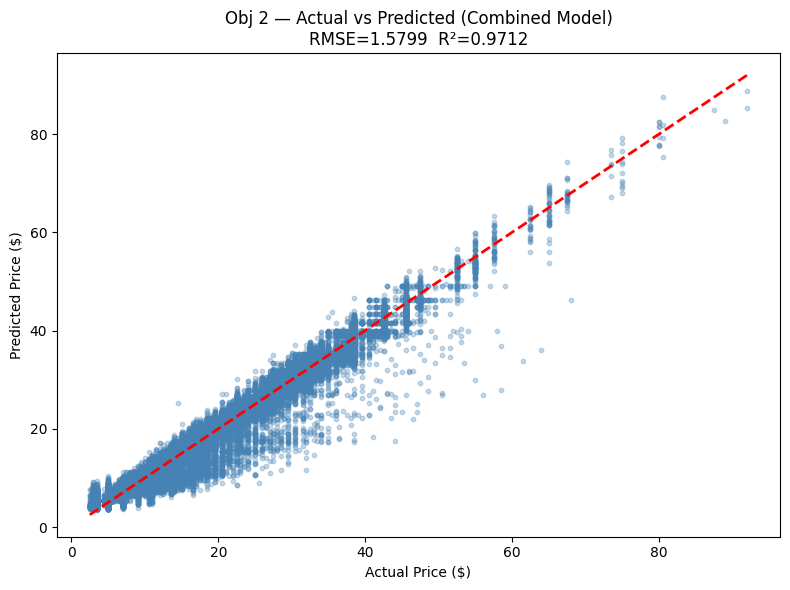

In [ ]:
# ================================================================
# OBJ 2: Actual vs Predicted (Using the winning HistGBM model)
# ================================================================
y_pred_all = model_hist_combined.predict(X_te_all)
 
plt.figure(figsize=(8, 6))
plt.scatter(y_te_all, y_pred_all, alpha=0.3, color='steelblue', s=10)
plt.plot([y_te_all.min(), y_te_all.max()],
         [y_te_all.min(), y_te_all.max()], '--r', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Obj 2 — Actual vs Predicted (Combined Model - HistGBM)\nRMSE={rmse_hist_combined:.4f}  R²={r2_hist_combined:.4f}')
plt.tight_layout()
plt.show()

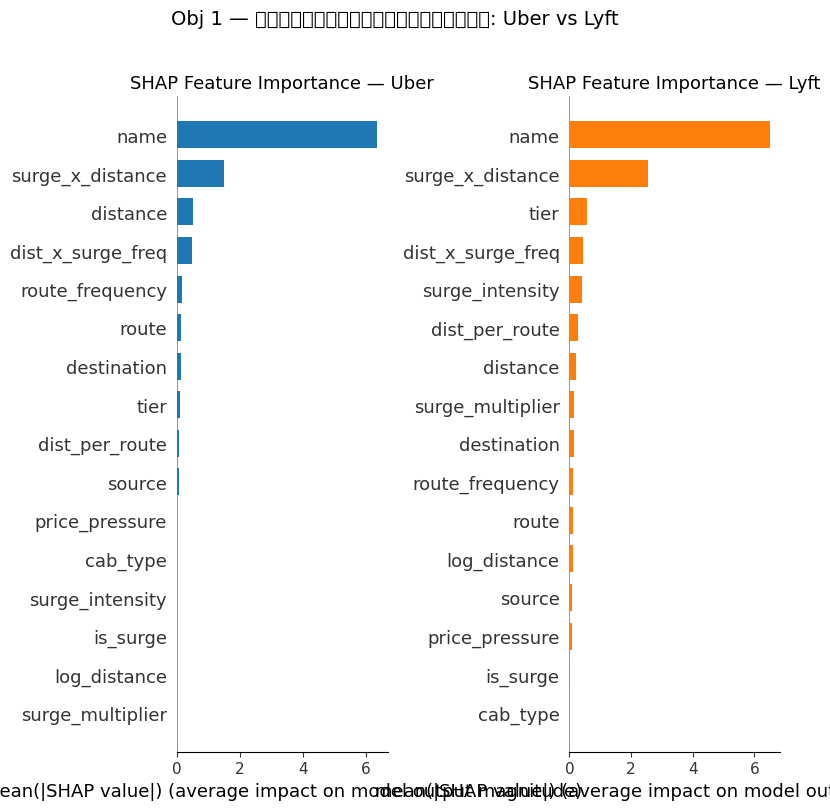


--- SHAP Beeswarm: Uber ---


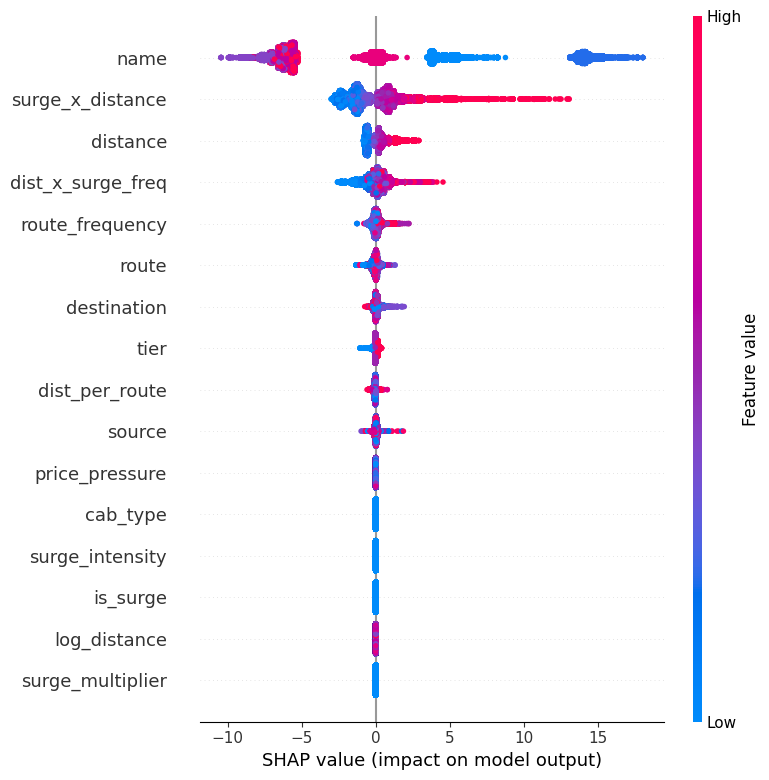


--- SHAP Beeswarm: Lyft ---


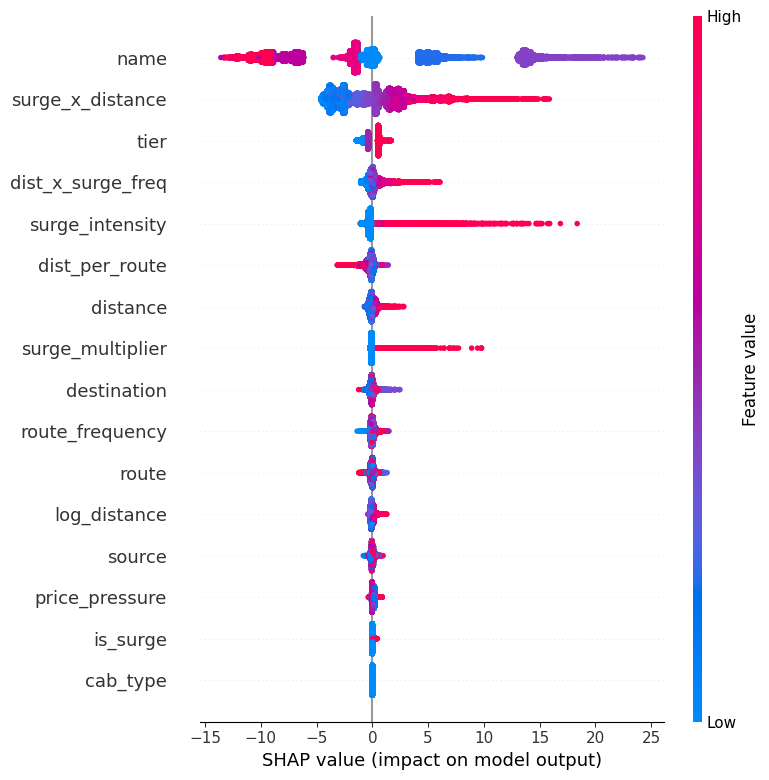

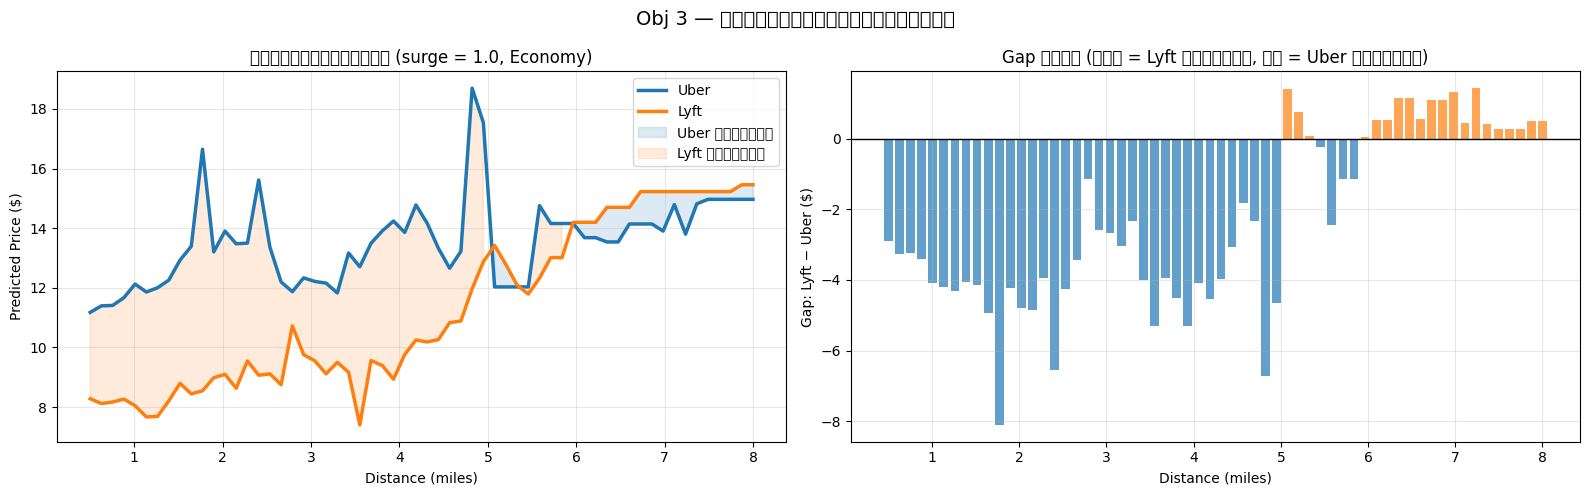


📌 ระยะทางที่ราคาใกล้เคียงกันที่สุด: ~6.0 miles
   ระยะสั้น (<6.0 mi): Lyft ถูกกว่า
   ระยะยาว (>6.0 mi): Uber ถูกกว่า


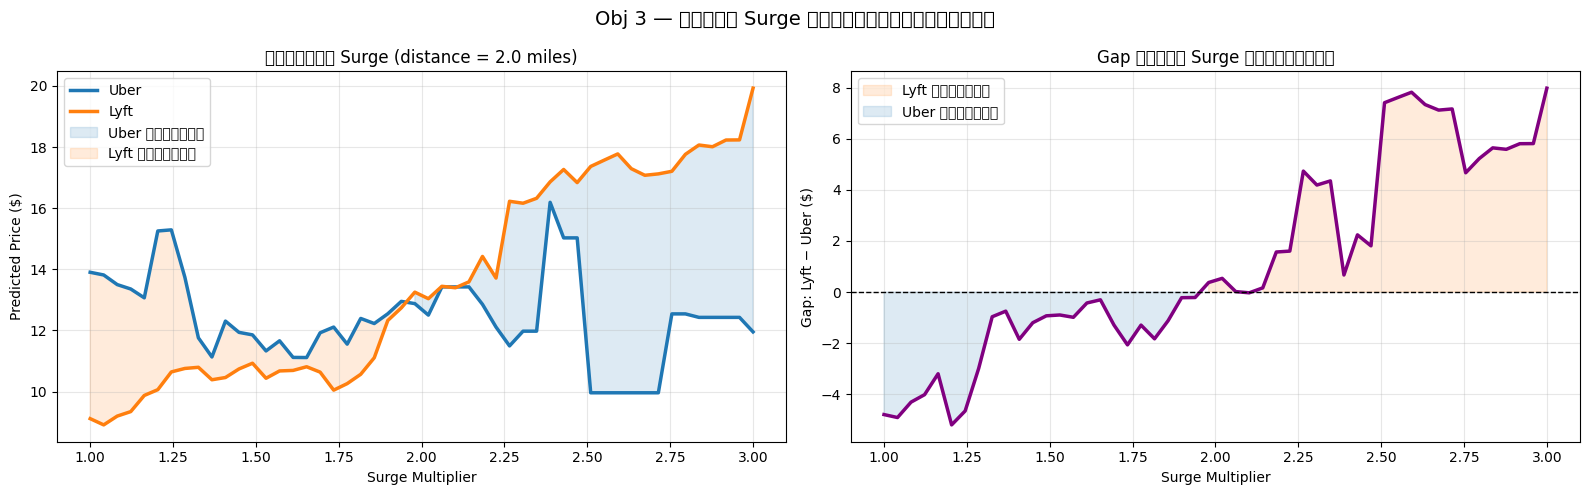


📌 Surge Sensitivity (ราคาเพิ่มต่อ 1 unit surge)
   Uber: +$-0.98 per surge unit
   Lyft: +$5.41 per surge unit
   → Lyft ราคาพุ่งแรงกว่าเมื่อ surge สูง


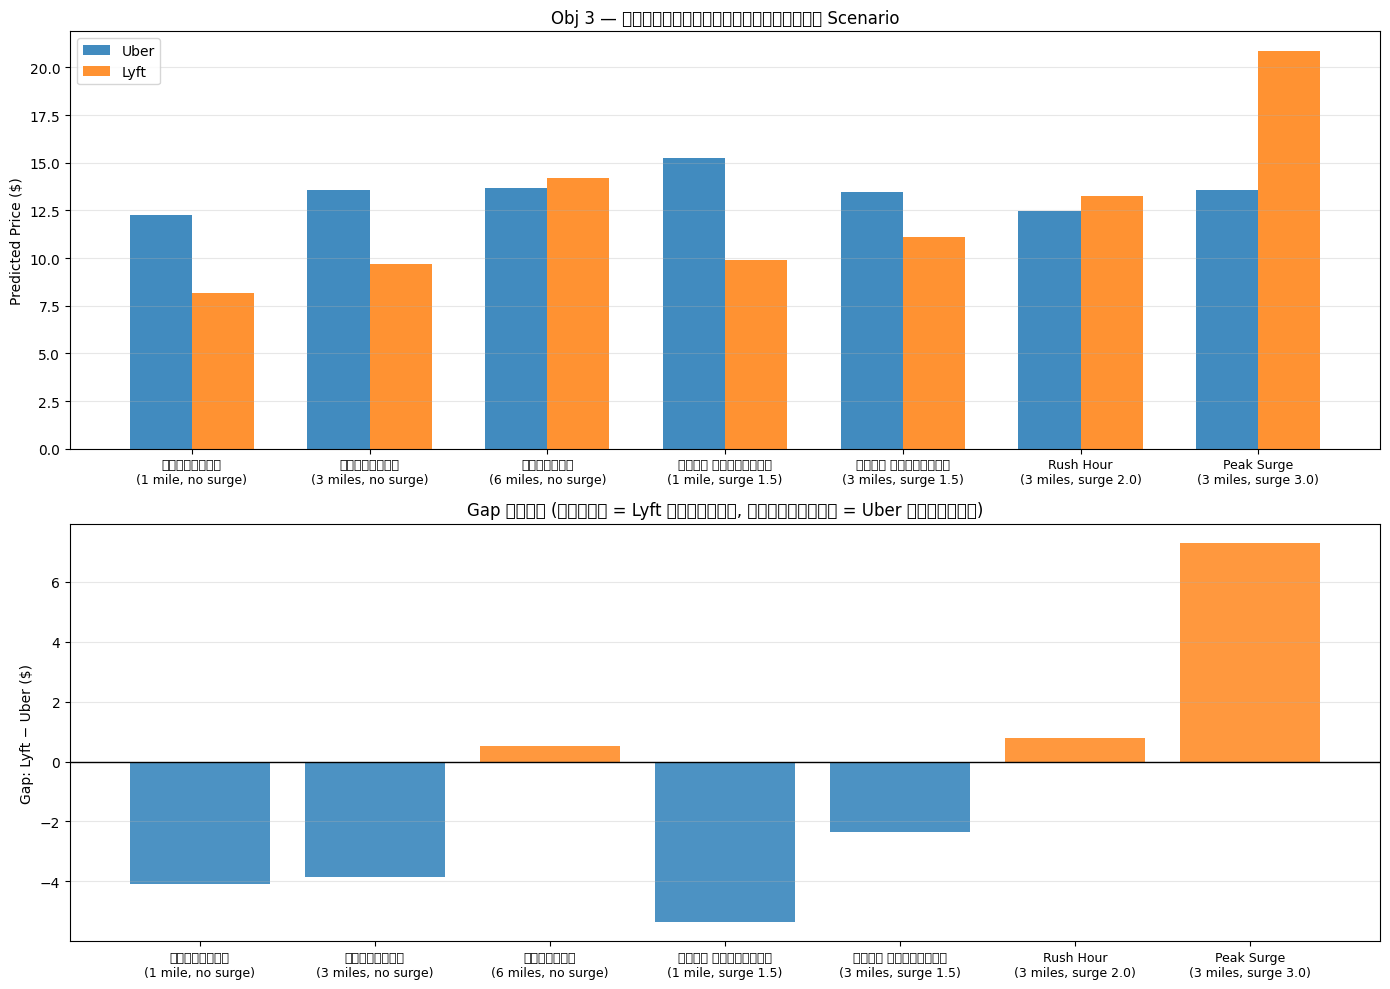


📊 สรุป Insight Obj 3 — ควรใช้เจ้าไหนในสถานการณ์ไหน

🔹 ระยะสั้น (1 mile, no surge)
   Uber $12.26  |  Lyft $8.17
   → Lyft ถูกกว่า $4.09

🔹 ระยะกลาง (3 miles, no surge)
   Uber $13.55  |  Lyft $9.70
   → Lyft ถูกกว่า $3.85

🔹 ระยะยาว (6 miles, no surge)
   Uber $13.68  |  Lyft $14.20
   → Uber ถูกกว่า $0.52

🔹 ฝนตก ระยะสั้น (1 mile, surge 1.5)
   Uber $15.25  |  Lyft $9.88
   → Lyft ถูกกว่า $5.36

🔹 ฝนตก ระยะกลาง (3 miles, surge 1.5)
   Uber $13.46  |  Lyft $11.10
   → Lyft ถูกกว่า $2.37

🔹 Rush Hour (3 miles, surge 2.0)
   Uber $12.45  |  Lyft $13.25
   → Uber ถูกกว่า $0.80

🔹 Peak Surge (3 miles, surge 3.0)
   Uber $13.56  |  Lyft $20.85
   → Uber ถูกกว่า $7.29


In [ ]:
# ================================================================
# OBJ 1: SHAP Feature Importance
# Note: Using LightGBM for SHAP because shap.TreeExplainer supports it natively
# ================================================================
explainer_uber = shap.TreeExplainer(model_lgbm_uber)
explainer_lyft = shap.TreeExplainer(model_lgbm_lyft)
 
shap_uber = explainer_uber.shap_values(X_te_uber)
shap_lyft = explainer_lyft.shap_values(X_te_lyft)
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
 
plt.sca(axes[0])
shap.summary_plot(shap_uber, X_te_uber, plot_type='bar',
                  show=False, color='#1f77b4')
axes[0].set_title('SHAP Feature Importance — Uber', fontsize=13)
 
plt.sca(axes[1])
shap.summary_plot(shap_lyft, X_te_lyft, plot_type='bar',
                  show=False, color='#ff7f0e')
axes[1].set_title('SHAP Feature Importance — Lyft', fontsize=13)
 
plt.suptitle('Obj 1 — Factors Affecting Price: Uber vs Lyft', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
 
# Beeswarm plot (Showing directions)
print("\n--- SHAP Beeswarm: Uber ---")
shap.summary_plot(shap_uber, X_te_uber, show=True)
 
print("\n--- SHAP Beeswarm: Lyft ---")
shap.summary_plot(shap_lyft, X_te_lyft, show=True)
 
 
# ================================================================
# CELL G — Obj 3: Gap Plot — Uber vs Lyft Price Scenarios
# Using the winning HistGBM models for prediction
# ================================================================
 
# ---- helper: Create scenario row ----
def make_scenario(distance, surge, is_raining=False,
                  source='Back Bay', destination='North End',
                  cab_type='Uber', name='UberX', tier='economy'):
    """
    Create 1 row of input features for prediction.
    Features unrelated to the scenario are fixed to median values.
    """
    route_freq = 500   # Median value
    row = {
        'surge_multiplier':  surge,
        'surge_x_distance':  surge * distance,
        'distance':          distance,
        'log_distance':      np.log1p(distance),
        'surge_intensity':   surge - 1.0,
        'is_surge':          int(surge > 1.0),
        'route_frequency':   route_freq,
        'dist_x_surge_freq': distance * surge / (route_freq + 1),
        'dist_per_route':    distance / (route_freq + 1),
        'price_pressure':    distance / (route_freq + 1) * surge,
        'source':            source,
        'destination':       destination,
        'cab_type':          cab_type,
        'name':              name,
        'tier':              tier,
        'route':             f'{source} - {destination}',
    }
    return row
 
 
def predict_price(model, enc, rows_df):
    """Encode and predict"""
    X = rows_df[feature_cols].copy()
    X[categorical_cols] = enc.transform(X[categorical_cols])
    return model.predict(X)
 
 
# ================================================================
# CELL H — Obj 3 Plot 1: Gap by Distance (Surge Fixed = 1.0)
# ================================================================
 
distances = np.linspace(0.5, 8, 60)
 
rows_uber = pd.DataFrame([
    make_scenario(d, surge=1.0, cab_type='Uber', name='UberX', tier='economy')
    for d in distances
])
rows_lyft = pd.DataFrame([
    make_scenario(d, surge=1.0, cab_type='Lyft', name='Lyft', tier='economy')
    for d in distances
])
 
price_uber_dist = predict_price(model_hist_uber, enc_uber, rows_uber)
price_lyft_dist = predict_price(model_hist_lyft, enc_lyft, rows_lyft)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
 
# Price lines
ax1.plot(distances, price_uber_dist, color='#1f77b4', lw=2.5, label='Uber')
ax1.plot(distances, price_lyft_dist, color='#ff7f0e', lw=2.5, label='Lyft')
ax1.fill_between(distances, price_uber_dist, price_lyft_dist,
                 where=(price_uber_dist < price_lyft_dist),
                 alpha=0.15, color='#1f77b4', label='Uber is cheaper')
ax1.fill_between(distances, price_uber_dist, price_lyft_dist,
                 where=(price_lyft_dist < price_uber_dist),
                 alpha=0.15, color='#ff7f0e', label='Lyft is cheaper')
ax1.set_xlabel('Distance (miles)')
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title('Price by Distance (Surge = 1.0, Economy)')
ax1.legend()
ax1.grid(alpha=0.3)
 
# Gap
gap = price_lyft_dist - price_uber_dist
ax2.bar(distances, gap,
        color=np.where(gap > 0, '#ff7f0e', '#1f77b4'),
        width=0.1, alpha=0.7)
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel('Distance (miles)')
ax2.set_ylabel('Price Gap: Lyft − Uber ($)')
ax2.set_title('Price Gap (Positive = Lyft is more expensive, Negative = Uber)')
ax2.grid(alpha=0.3)
 
plt.suptitle('Obj 3 — Price Comparison by Distance', fontsize=14)
plt.tight_layout()
plt.show()
 
# Breakpoint Summary
crossover = distances[np.argmin(np.abs(gap))]
print(f"\n📌 Distance where prices are closest: ~{crossover:.1f} miles")
cheaper_short = 'Uber' if gap[0] > 0 else 'Lyft'
cheaper_long  = 'Uber' if gap[-1] > 0 else 'Lyft'
print(f"   Short Distance (<{crossover:.1f} mi): {cheaper_short} is cheaper")
print(f"   Long Distance (>{crossover:.1f} mi): {cheaper_long} is cheaper")
 
 
# ================================================================
# CELL I — Obj 3 Plot 2: Gap by Surge Multiplier (Fixed Dist = 2 miles)
# ================================================================
 
surges = np.linspace(1.0, 3.0, 50)
FIXED_DIST = 2.0
 
rows_uber_s = pd.DataFrame([
    make_scenario(FIXED_DIST, s, cab_type='Uber', name='UberX', tier='economy')
    for s in surges
])
rows_lyft_s = pd.DataFrame([
    make_scenario(FIXED_DIST, s, cab_type='Lyft', name='Lyft', tier='economy')
    for s in surges
])
 
price_uber_surge = predict_price(model_hist_uber, enc_uber, rows_uber_s)
price_lyft_surge = predict_price(model_hist_lyft, enc_lyft, rows_lyft_s)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
 
ax1.plot(surges, price_uber_surge, color='#1f77b4', lw=2.5, label='Uber')
ax1.plot(surges, price_lyft_surge, color='#ff7f0e', lw=2.5, label='Lyft')
ax1.fill_between(surges, price_uber_surge, price_lyft_surge,
                 where=(price_uber_surge < price_lyft_surge),
                 alpha=0.15, color='#1f77b4', label='Uber is cheaper')
ax1.fill_between(surges, price_uber_surge, price_lyft_surge,
                 where=(price_lyft_surge < price_uber_surge),
                 alpha=0.15, color='#ff7f0e', label='Lyft is cheaper')
ax1.set_xlabel('Surge Multiplier')
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title(f'Price by Surge (Distance = {FIXED_DIST} miles)')
ax1.legend()
ax1.grid(alpha=0.3)
 
gap_s = price_lyft_surge - price_uber_surge
ax2.plot(surges, gap_s, color='purple', lw=2.5)
ax2.axhline(0, color='black', lw=1, linestyle='--')
ax2.fill_between(surges, gap_s, 0,
                 where=(gap_s > 0), alpha=0.15, color='#ff7f0e', label='Lyft is more expensive')
ax2.fill_between(surges, gap_s, 0,
                 where=(gap_s < 0), alpha=0.15, color='#1f77b4', label='Uber is more expensive')
ax2.set_xlabel('Surge Multiplier')
ax2.set_ylabel('Price Gap: Lyft − Uber ($)')
ax2.set_title('Gap as Surge Increases')
ax2.legend()
ax2.grid(alpha=0.3)
 
plt.suptitle('Obj 3 — Effect of Surge on Prices', fontsize=14)
plt.tight_layout()
plt.show()
 
# Surge sensitivity summary
slope_uber = (price_uber_surge[-1] - price_uber_surge[0]) / (surges[-1] - surges[0])
slope_lyft = (price_lyft_surge[-1] - price_lyft_surge[0]) / (surges[-1] - surges[0])
print(f"\n📌 Surge Sensitivity (Price increase per 1 unit surge)")
print(f"   Uber: +${slope_uber:.2f} per surge unit")
print(f"   Lyft: +${slope_lyft:.2f} per surge unit")
more_sensitive = 'Lyft' if slope_lyft > slope_uber else 'Uber'
print(f"   → {more_sensitive} price increases faster at high surge")
 
 
# ================================================================
# CELL J — Obj 3: Scenario Insight Summary
# ================================================================
 
scenarios = [
    {'label': 'Short Distance\n(1 mile, no surge)',    'dist': 1.0, 'surge': 1.0},
    {'label': 'Medium Distance\n(3 miles, no surge)',   'dist': 3.0, 'surge': 1.0},
    {'label': 'Long Distance\n(6 miles, no surge)',    'dist': 6.0, 'surge': 1.0},
    {'label': 'Rain & Short\n(1 mile, surge 1.5)', 'dist': 1.0, 'surge': 1.5},
    {'label': 'Rain & Medium\n(3 miles, surge 1.5)', 'dist': 3.0, 'surge': 1.5},
    {'label': 'Rush Hour\n(3 miles, surge 2.0)', 'dist': 3.0, 'surge': 2.0},
    {'label': 'Peak Surge\n(3 miles, surge 3.0)', 'dist': 3.0, 'surge': 3.0},
]
 
labels, uber_prices, lyft_prices, gaps_sc = [], [], [], []
 
for sc in scenarios:
    row_u = pd.DataFrame([make_scenario(sc['dist'], sc['surge'], cab_type='Uber', name='UberX', tier='economy')])
    row_l = pd.DataFrame([make_scenario(sc['dist'], sc['surge'], cab_type='Lyft', name='Lyft',  tier='economy')])
 
    p_u = predict_price(model_hist_uber, enc_uber, row_u)[0]
    p_l = predict_price(model_hist_lyft, enc_lyft, row_l)[0]
 
    labels.append(sc['label'])
    uber_prices.append(p_u)
    lyft_prices.append(p_l)
    gaps_sc.append(p_l - p_u)
 
x = np.arange(len(labels))
width = 0.35
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
 
# Bar chart
bars_u = ax1.bar(x - width/2, uber_prices, width, color='#1f77b4', alpha=0.85, label='Uber')
bars_l = ax1.bar(x + width/2, lyft_prices, width, color='#ff7f0e', alpha=0.85, label='Lyft')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('Predicted Price ($)')
ax1.set_title('Obj 3 — Price Comparison by Scenario')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# Gap bar
colors = ['#ff7f0e' if g > 0 else '#1f77b4' for g in gaps_sc]
ax2.bar(x, gaps_sc, color=colors, alpha=0.8)
ax2.axhline(0, color='black', lw=1)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel('Price Gap: Lyft − Uber ($)')
ax2.set_title('Price Gap (Orange = Lyft is more expensive, Blue = Uber is more expensive)')
ax2.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.show()
 
# ---- Text Summary ----
print("\n" + "="*55)
print("📊 Scenario Insight Summary — Which service to choose?")
print("="*55)
for i, sc in enumerate(scenarios):
    winner = 'Uber' if gaps_sc[i] > 0 else 'Lyft'
    diff   = abs(gaps_sc[i])
    print(f"\n🔹 {sc['label'].replace(chr(10), ' ')}")
    print(f"   Uber ${uber_prices[i]:.2f}  |  Lyft ${lyft_prices[i]:.2f}")
    print(f"   → {winner} is cheaper by ${diff:.2f}")


📊 สรุปผลการทำงานสำหรับชุดข้อมูล: Uber


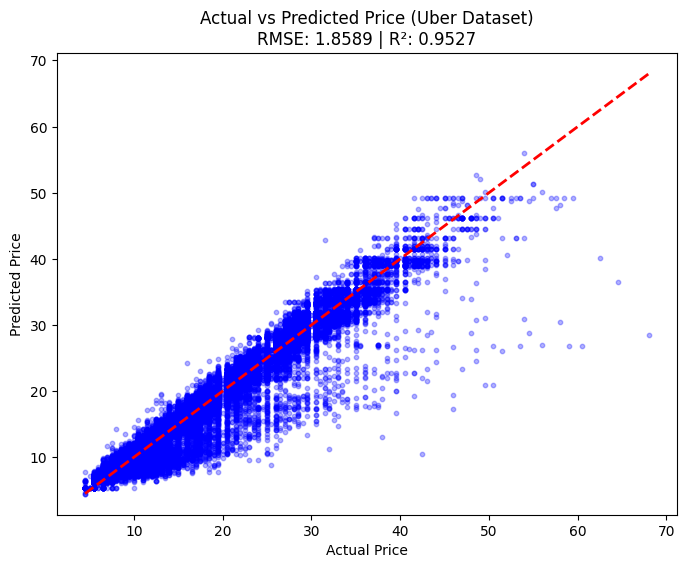

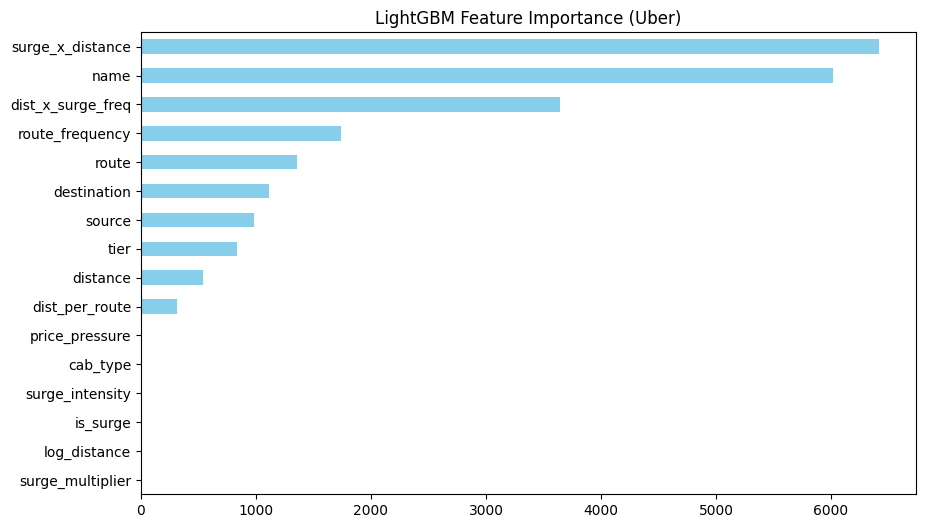

กำลังคำนวณ Permutation Importance สำหรับ Uber (อาจใช้เวลาสักครู่...)



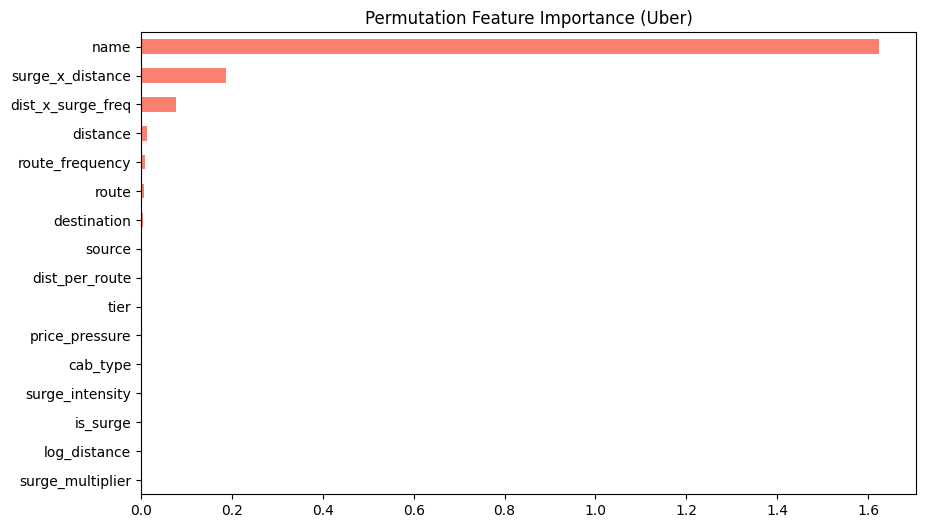


📊 สรุปผลการทำงานสำหรับชุดข้อมูล: Lyft


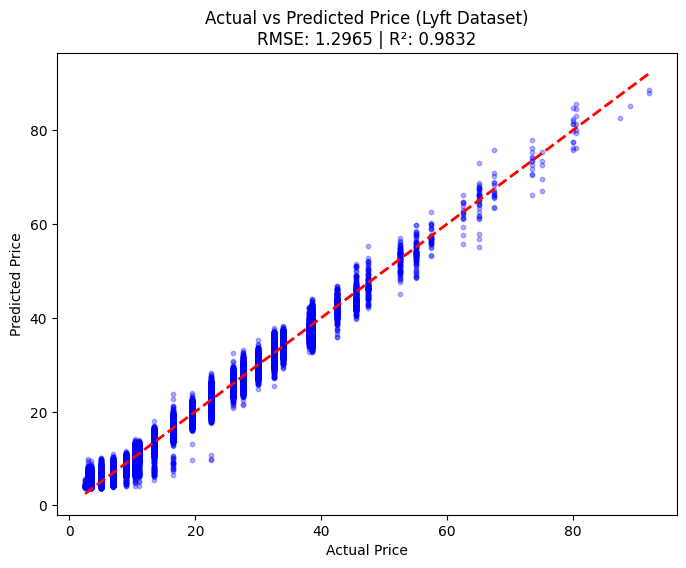

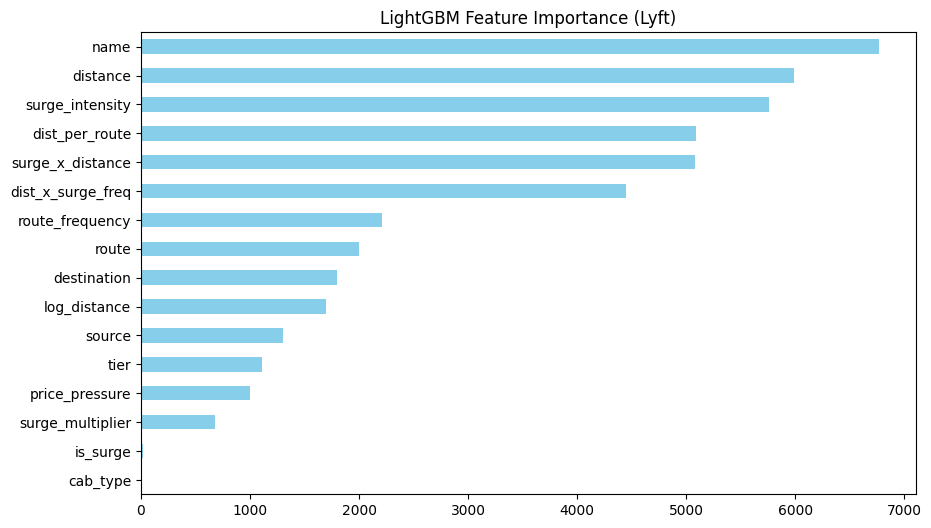

กำลังคำนวณ Permutation Importance สำหรับ Lyft (อาจใช้เวลาสักครู่...)



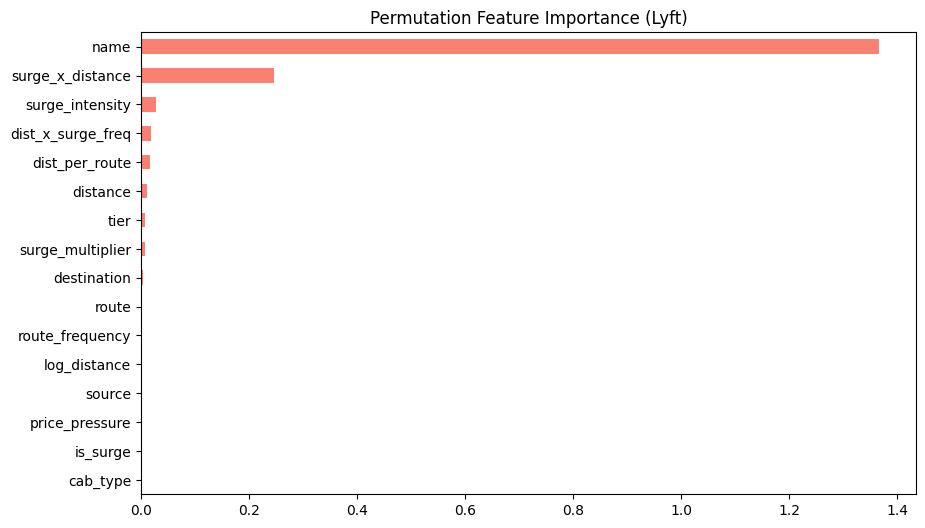


📊 สรุปผลการทำงานสำหรับชุดข้อมูล: Combined


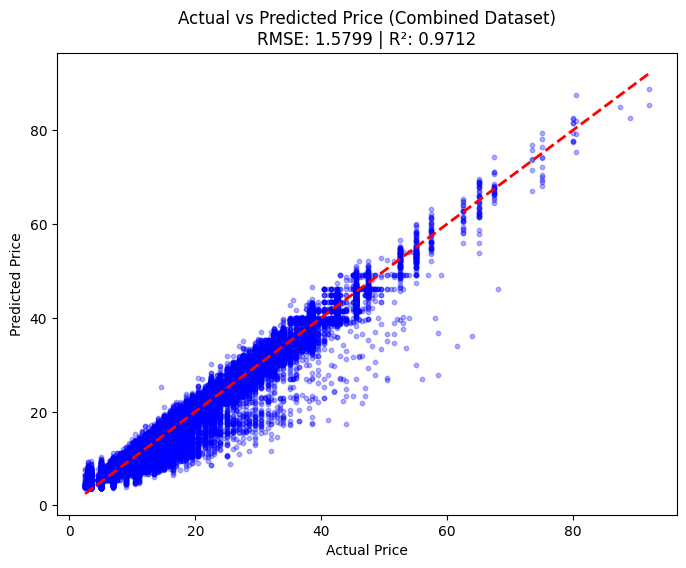

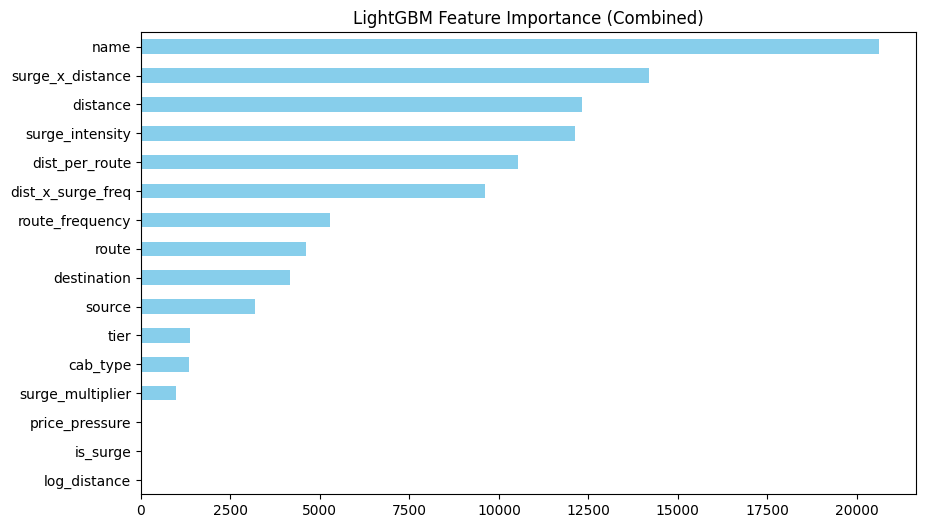

กำลังคำนวณ Permutation Importance สำหรับ Combined (อาจใช้เวลาสักครู่...)



KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# 1. เตรียมข้อมูลโมเดลและ Dataset ให้พร้อม (ดึงมาจากผลลัพธ์ของ Optuna)
model_results = {
    'Uber': {'model': model_uber, 'X_tr': X_tr_uber, 'y_tr': y_tr_uber, 'X_te': X_te_uber, 'y_te': y_te_uber},
    'Lyft': {'model': model_lyft, 'X_tr': X_tr_lyft, 'y_tr': y_tr_lyft, 'X_te': X_te_lyft, 'y_te': y_te_lyft},
    'Combined': {'model': model_combined, 'X_tr': X_tr_all, 'y_tr': y_tr_all, 'X_te': X_te_all, 'y_te': y_te_all}
}

# 2. วนลูปพล็อตกราฟทีละ Dataset (หน้าตาเหมือนโค้ดเก่าของคุณเลยครับ)
for ds_name, data in model_results.items():
    print(f"\n{'='*60}")
    print(f"📊 สรุปผลการทำงานสำหรับชุดข้อมูล: {ds_name}")
    print(f"{'='*60}")
    
    best_model = data['model']
    X_test = data['X_te']
    y_test = data['y_te']
    X_train = data['X_tr']
    
    # ---------------------------------------------------------
    # กราฟที่ 1: Actual vs Predicted
    # ---------------------------------------------------------
    y_pred = best_model.predict(X_test)
    final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    final_r2 = r2_score(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue', s=10)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Actual vs Predicted Price ({ds_name} Dataset)\nRMSE: {final_rmse:.4f} | R²: {final_r2:.4f}')
    plt.show()

    # ---------------------------------------------------------
    # กราฟที่ 2: Feature Importance (พล็อตแบบใช้คำสั่งของโมเดลโดยตรง)
    # หมายเหตุ: ของ LightGBM จะเรียกว่า feature_importances_ เหมือนกัน
    # ---------------------------------------------------------
    importance_df = pd.Series(best_model.feature_importances_, index=X_train.columns)
    
    plt.figure(figsize=(10, 6))
    importance_df.sort_values(ascending=True).plot(kind='barh', color='skyblue')
    plt.title(f'LightGBM Feature Importance ({ds_name})')
    plt.show()

    # ---------------------------------------------------------
    # กราฟที่ 3: Permutation Importance
    # ---------------------------------------------------------
    print(f"กำลังคำนวณ Permutation Importance สำหรับ {ds_name} (อาจใช้เวลาสักครู่...)\n")
    # ปรับ n_repeats ให้ลดลงเหลือ 5 ก่อน เพื่อความรวดเร็วในการทดสอบ (ถ้าชัวร์แล้วค่อยปรับกลับเป็น 10 ได้ครับ)
    result = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    
    hist_importance = pd.Series(result.importances_mean, index=X_test.columns)
    
    plt.figure(figsize=(10, 6))
    hist_importance.sort_values(ascending=True).plot(kind='barh', color='salmon')
    plt.title(f'Permutation Feature Importance ({ds_name})')
    plt.show()
    
print("\n🎉 พล็อตกราฟสรุปผลครบทั้ง 3 Dataset เรียบร้อยแล้วครับ!")